# **ECE-2112-PA-4**

#### Julian Patrick C. Herrera | 2ECE-C

*This repository contains three programming problems which covers **Module 1 - Base Computing with Python**.*

**Objectives:**

1. filter tabular data using several categorical and numerical conditions;
2. construct focused DataFrames by selecting relevant features;
3. summarize the relationship between categorical features and a numerical variable; and
4. communicate a data comparison using clear and correctly labeled plots.

In [45]:
import pandas as pd
df = pd.read_excel("board2.xlsx")

## **A. Visayas Communication Dataframe**

Create a **DataFrame** named ```VisComm``` containing students whose Hometown is **Visayas** and whose Track
is **Communication**. Retain only these columns, in the stated order:

```Name, Gender, Math, Electronics, Average```

Display the resulting DataFrame and its number of rows. Both filtering conditions must be applied to the source dataset before the columns are selected.

In [46]:
filtered_df = df[
    (df["Hometown"] == "Visayas") & (df["Track"] == "Communication")
].copy()
filtered_df["Average"] = filtered_df[["Math", "Electronics"]].mean(axis=1)
columns = ["Name", "Gender", "Math", "Electronics", "Average"]
VisComm = filtered_df[columns].copy()

In [47]:
print(VisComm)

   Name  Gender  Math  Electronics  Average
10  S11  Female    48           56     52.0
11  S12    Male    89           67     78.0
17  S18    Male    81           40     60.5
21  S22  Female    64           39     51.5
27  S28    Male    85           53     69.0


In [48]:
print(f"Number of rows: {len(VisComm)}")

Number of rows: 5


## **B. Visayas Female Dataframe**

Create a second **DataFrame** named **VisFemale** containing students whose Hometown is Visayas and
whose Gender is Female. Retain only:

```Name, Track, GEAS, Electronics, Average```

Display **VisFemale**. Then display only the rows of VisFemale whose Average is at least 60. Do not overwrite **VisFemale** when performing this second filter.

In [49]:
filtered_female = df[(df["Hometown"] == "Visayas") & (df["Gender"] == "Female")]
female_columns = ["Name", "Track", "GEAS", "Electronics", "Average"]
VisFemale = filtered_female[female_columns].copy()

In [50]:
print("\n--- VisFemale with Average >= 60 ---")
print(VisFemale[VisFemale["Average"] >= 60])


--- VisFemale with Average >= 60 ---
   Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
25  S26   Instrumentation    83           47    65.75


## **C. Category-Average Visualization**

Examine how the recorded Average differs across the three categorical features Track, Gender, and Hometown.

> **a.** For each feature, compute the mean of ```Average``` for every category using Pandas.

> **b.** Display the three summary tables.

> **c.** Create one figure containing three bar charts: mean Average by Track, by Gender, and by Hometown.

> **d.** Below the figure, write three concise statements identifying the category with the highest sample mean for each feature.

**Interpretation rule:** Describe the observed dataset only. A difference in group means does not, by itself, establish that a feature causes a higher board-exam score.

In [51]:
import matplotlib.pyplot as plt

In [52]:
mean_track = df.groupby("Track")["Average"].mean().reset_index()
mean_gender = df.groupby("Gender")["Average"].mean().reset_index()
mean_hometown = df.groupby("Hometown")["Average"].mean().reset_index()

In [53]:
print("Mean Average by Track:")
print(mean_track)
print("\nMean Average by Gender:")
print(mean_gender)
print("\nMean Average by Hometown:")
print(mean_hometown)

Mean Average by Track:
              Track  Average
0     Communication   67.975
1   Instrumentation   65.225
2  Microelectronics   67.500

Mean Average by Gender:
   Gender    Average
0  Female  66.616667
1    Male  67.183333

Mean Average by Hometown:
   Hometown    Average
0     Luzon  68.083333
1  Mindanao  66.678571
2   Visayas  65.750000


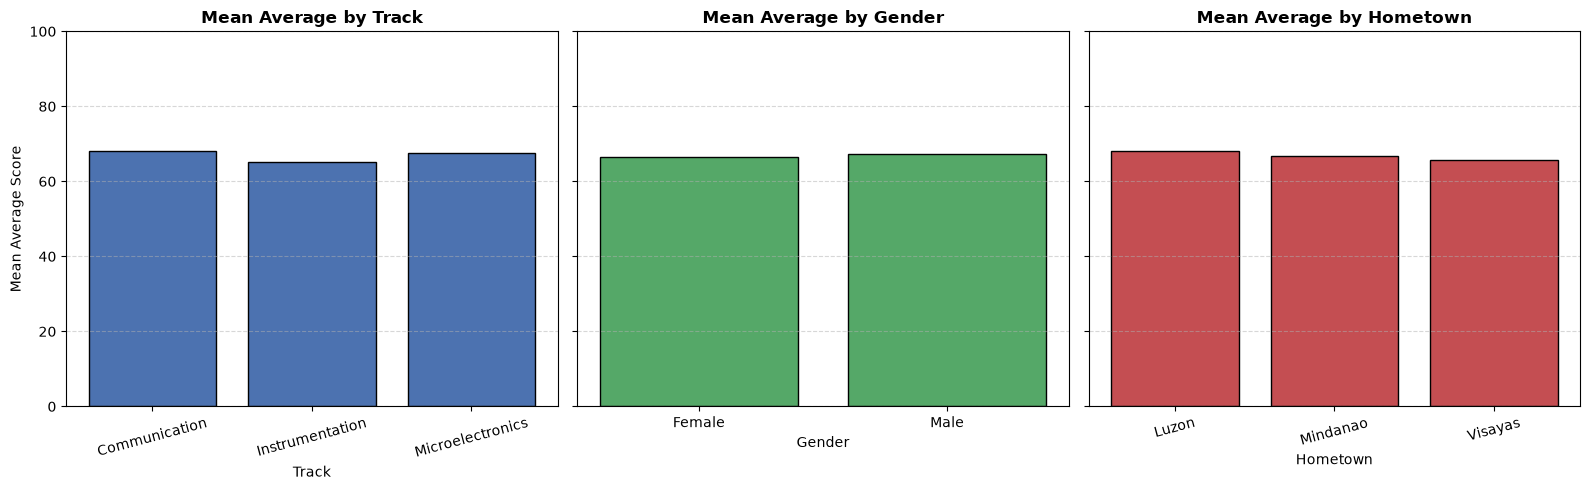

1. Track: The Communication track achieved the highest sample mean (67.97).
2. Gender: Male students recorded the highest sample mean (67.18).
3. Hometown: Students from Luzon obtained the highest sample mean (68.08).


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Bar Chart by Track
axes[0].bar(
    mean_track["Track"],
    mean_track["Average"],
    color="#4C72B0",
    edgecolor="black",
)
axes[0].set_title("Mean Average by Track", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Track", fontsize=10)
axes[0].set_ylabel("Mean Average Score", fontsize=10)
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
# Bar Chart by Gender
axes[1].bar(
    mean_gender["Gender"],
    mean_gender["Average"],
    color="#55A868",
    edgecolor="black",
)
axes[1].set_title("Mean Average by Gender", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Gender", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# Bar Chart by Hometown
axes[2].bar(
    mean_hometown["Hometown"],
    mean_hometown["Average"],
    color="#C44E52",
    edgecolor="black",
)
axes[2].set_title("Mean Average by Hometown", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Hometown", fontsize=10)
axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)


axes[0].set_ylim(0, 100)

plt.tight_layout()
plt.show()

top_track = df.groupby("Track")["Average"].mean().idxmax()
top_track_val = df.groupby("Track")["Average"].mean().max()

top_gender = df.groupby("Gender")["Average"].mean().idxmax()
top_gender_val = df.groupby("Gender")["Average"].mean().max()

top_hometown = df.groupby("Hometown")["Average"].mean().idxmax()
top_hometown_val = df.groupby("Hometown")["Average"].mean().max()

print(
    f"1. Track: The {top_track} track achieved the highest sample mean ({top_track_val:.2f})."
)
print(
    f"2. Gender: {top_gender} students recorded the highest sample mean ({top_gender_val:.2f})."
)
print(
    f"3. Hometown: Students from {top_hometown} obtained the highest sample mean ({top_hometown_val:.2f})."
)